# 02 — WESAD Sample Analysis: S2 Proof-of-Concept

This notebook analyzes **one WESAD subject first** (`S2`) before expanding to all participants.

Goal of this notebook:
1. Load one synchronized WESAD `.pkl` file.
2. Inspect physiological signals and labels.
3. Extract simple 60-second window features.
4. Run preliminary visualizations.
5. Train a small baseline stress vs. non-stress model.
6. Save the processed feature table for later expansion.

This single-subject analysis establishes the initial feasibility of extracting multimodal physiological features and evaluating latent wellness-related patterns before extending the workflow to subject-independent validation.


In [ ]:
# ============================================================
# STEP 1. Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# STEP 2. Import libraries
# ============================================================
import os
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)

In [ ]:
# ============================================================
# STEP 3. Define project paths
# Root directory for the analysis project.
# ============================================================
PROJECT_ROOT = "/content/drive/MyDrive/Apple_Hidden_Wellness_AI"
RAW_WESAD_DIR = os.path.join(PROJECT_ROOT, "data", "raw", "WESAD", "WESAD")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("RAW_WESAD_DIR:", RAW_WESAD_DIR)
print("Exists:", os.path.exists(RAW_WESAD_DIR))

RAW_WESAD_DIR: /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD
Exists: True


In [ ]:
# ============================================================
# STEP 4. Find available subject pkl files
# ============================================================
pkl_files = sorted(glob.glob(os.path.join(RAW_WESAD_DIR, "S*", "S*.pkl")))

print("Number of pkl files:", len(pkl_files))
for f in pkl_files[:10]:
    print(f)

if len(pkl_files) == 0:
    raise FileNotFoundError("No .pkl files found. Check RAW_WESAD_DIR path.")

Number of pkl files: 15
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S10/S10.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S11/S11.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S13/S13.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S14/S14.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S15/S15.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S16/S16.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S17/S17.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S2/S2.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S3/S3.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S4/S4.pkl


In [ ]:
# ============================================================
# STEP 5. Load one subject first: S2
# ============================================================
SUBJECT = "S2"
pkl_path = os.path.join(RAW_WESAD_DIR, SUBJECT, f"{SUBJECT}.pkl")

if not os.path.exists(pkl_path):
    raise FileNotFoundError(f"Could not find {pkl_path}")

with open(pkl_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print("Main keys:", data.keys())
print("Signal keys:", data["signal"].keys())
print("Chest keys:", data["signal"]["chest"].keys())
print("Wrist keys:", data["signal"]["wrist"].keys())
print("Unique labels:", sorted(set(data["label"])))

Main keys: dict_keys(['signal', 'label', 'subject'])
Signal keys: dict_keys(['chest', 'wrist'])
Chest keys: dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])
Wrist keys: dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])
Unique labels: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(6), np.int32(7)]


## WESAD labels used here

WESAD labels:
- `1 = baseline`
- `2 = stress`
- `3 = amusement`
- `4 = meditation`

For the first proof-of-concept model, we use:
- `0 = non-stress / baseline`
- `1 = stress`

We ignore amusement and meditation for this first simple model.


In [ ]:
# ============================================================
# STEP 6. Extract chest signals and labels
# Chest signals are sampled at 700 Hz in WESAD.
# ============================================================
chest = data["signal"]["chest"]

# Print shapes
for key, value in chest.items():
    try:
        print(key, np.asarray(value).shape)
    except Exception:
        print(key, type(value))

labels = np.asarray(data["label"]).flatten()
print("Labels shape:", labels.shape)

# Extract important signals
ecg = np.asarray(chest["ECG"]).flatten()
eda = np.asarray(chest["EDA"]).flatten()
temp_key = "Temp" if "Temp" in chest else "TEMP"
temp = np.asarray(chest[temp_key]).flatten()
resp = np.asarray(chest["Resp"]).flatten()

# ACC may be 3D
acc = np.asarray(chest["ACC"])
if acc.ndim == 2 and acc.shape[1] == 3:
    acc_mag = np.sqrt(np.sum(acc**2, axis=1))
else:
    acc_mag = np.asarray(acc).flatten()

print("ECG:", ecg.shape)
print("EDA:", eda.shape)
print("TEMP:", temp.shape)
print("RESP:", resp.shape)
print("ACC magnitude:", acc_mag.shape)
print("Labels:", labels.shape)

ACC (4255300, 3)
ECG (4255300, 1)
EMG (4255300, 1)
EDA (4255300, 1)
Temp (4255300, 1)
Resp (4255300, 1)
Labels shape: (4255300,)
ECG: (4255300,)
EDA: (4255300,)
TEMP: (4255300,)
RESP: (4255300,)
ACC magnitude: (4255300,)
Labels: (4255300,)


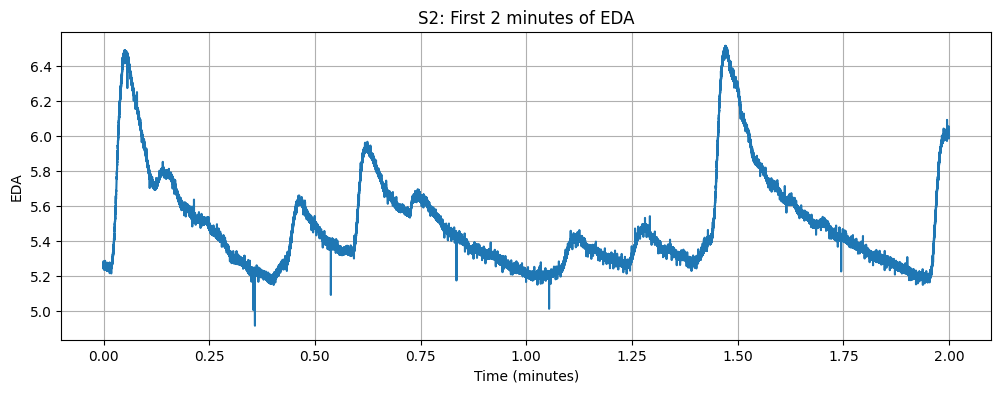

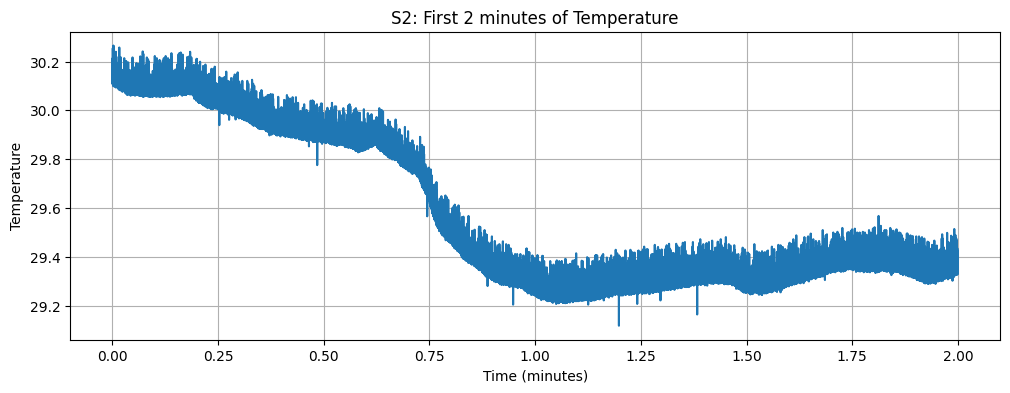

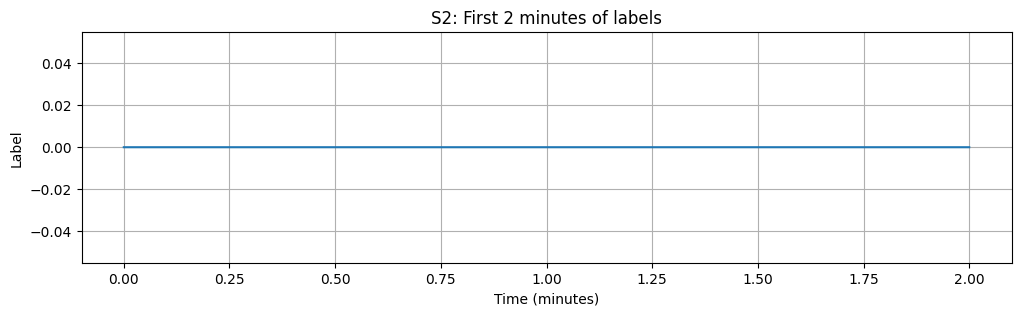

In [ ]:
# ============================================================
# STEP 7. Plot a short signal segment to visually inspect data
# ============================================================
fs = 700  # chest sampling frequency
minutes_to_plot = 2
n = fs * 60 * minutes_to_plot

time_min = np.arange(n) / fs / 60

plt.figure(figsize=(12, 4))
plt.plot(time_min, eda[:n])
plt.xlabel("Time (minutes)")
plt.ylabel("EDA")
plt.title(f"{SUBJECT}: First {minutes_to_plot} minutes of EDA")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(time_min, temp[:n])
plt.xlabel("Time (minutes)")
plt.ylabel("Temperature")
plt.title(f"{SUBJECT}: First {minutes_to_plot} minutes of Temperature")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(time_min, labels[:n])
plt.xlabel("Time (minutes)")
plt.ylabel("Label")
plt.title(f"{SUBJECT}: First {minutes_to_plot} minutes of labels")
plt.grid(True)
plt.show()

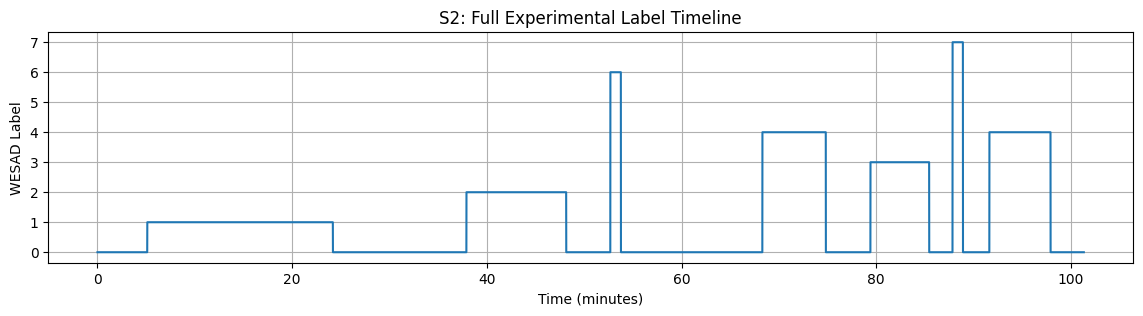

In [ ]:
# ============================================================
# STEP 7B. Plot full experimental label timeline
# ============================================================
fs = 700
time_min = np.arange(len(labels)) / fs / 60

plt.figure(figsize=(14, 3))
plt.plot(time_min, labels)
plt.xlabel("Time (minutes)")
plt.ylabel("WESAD Label")
plt.title(f"{SUBJECT}: Full Experimental Label Timeline")
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# STEP 8. Helper function: window feature extraction
# ============================================================
def extract_window_features_for_subject(data, subject_id, window_sec=60, step_sec=30, fs=700):
    """
    Extract simple statistical features from chest signals using sliding windows.

    Returns:
        DataFrame with one row per window.
    """
    chest = data["signal"]["chest"]
    labels = np.asarray(data["label"]).flatten()

    ecg = np.asarray(chest["ECG"]).flatten()
    eda = np.asarray(chest["EDA"]).flatten()
    temp_key = "Temp" if "Temp" in chest else "TEMP"
    temp = np.asarray(chest[temp_key]).flatten()
    resp = np.asarray(chest["Resp"]).flatten()

    acc = np.asarray(chest["ACC"])
    if acc.ndim == 2 and acc.shape[1] == 3:
        acc_mag = np.sqrt(np.sum(acc**2, axis=1))
    else:
        acc_mag = np.asarray(acc).flatten()

    min_len = min(len(ecg), len(eda), len(temp), len(resp), len(acc_mag), len(labels))
    ecg, eda, temp, resp, acc_mag, labels = (
        ecg[:min_len],
        eda[:min_len],
        temp[:min_len],
        resp[:min_len],
        acc_mag[:min_len],
        labels[:min_len],
    )

    window_size = int(window_sec * fs)
    step_size = int(step_sec * fs)

    rows = []

    for start in range(0, min_len - window_size, step_size):
        end = start + window_size
        y_window = labels[start:end]

        # Keep only windows where majority label is baseline or stress.
        values, counts = np.unique(y_window, return_counts=True)
        majority_label = values[np.argmax(counts)]

        if majority_label not in [1, 2]:
            continue

        # Require at least 80% of the window to be the majority label.
        if np.max(counts) / len(y_window) < 0.80:
            continue

        # Convert label: baseline = 0, stress = 1
        y = 1 if majority_label == 2 else 0

        row = {
            "subject": subject_id,
            "start_sec": start / fs,
            "end_sec": end / fs,
            "label": y,

            "ECG_mean": np.mean(ecg[start:end]),
            "ECG_std": np.std(ecg[start:end]),
            "ECG_min": np.min(ecg[start:end]),
            "ECG_max": np.max(ecg[start:end]),

            "EDA_mean": np.mean(eda[start:end]),
            "EDA_std": np.std(eda[start:end]),
            "EDA_min": np.min(eda[start:end]),
            "EDA_max": np.max(eda[start:end]),

            "TEMP_mean": np.mean(temp[start:end]),
            "TEMP_std": np.std(temp[start:end]),
            "TEMP_min": np.min(temp[start:end]),
            "TEMP_max": np.max(temp[start:end]),

            "RESP_mean": np.mean(resp[start:end]),
            "RESP_std": np.std(resp[start:end]),
            "RESP_min": np.min(resp[start:end]),
            "RESP_max": np.max(resp[start:end]),

            "ACC_mean": np.mean(acc_mag[start:end]),
            "ACC_std": np.std(acc_mag[start:end]),
            "ACC_min": np.min(acc_mag[start:end]),
            "ACC_max": np.max(acc_mag[start:end]),
        }

        rows.append(row)

    return pd.DataFrame(rows)

In [ ]:
# ============================================================
# STEP 9. Extract features for S2 only
# ============================================================
df_s2 = extract_window_features_for_subject(
    data=data,
    subject_id=SUBJECT,
    window_sec=60,
    step_sec=30,
    fs=700
)

print(df_s2.shape)
display(df_s2.head())
print(df_s2["label"].value_counts())

(56, 24)


,subject,start_sec,end_sec,label,ECG_mean,ECG_std,ECG_min,ECG_max,EDA_mean,EDA_std,EDA_min,EDA_max,TEMP_mean,TEMP_std,TEMP_min,TEMP_max,RESP_mean,RESP_std,RESP_min,RESP_max,ACC_mean,ACC_std,ACC_min,ACC_max
0,S2,300.0,360.0,0,0.001466,0.136763,-0.435883,0.979294,5.037455,0.302370,4.555511,5.957413,29.167696,0.060271,29.011780,29.426208,-0.041239,2.873152,-8.805847,6.742859,0.937691,0.024250,0.710656,1.217648
1,S2,330.0,390.0,0,0.001360,0.149064,-0.435883,0.833313,4.587706,0.228968,4.127884,5.094528,29.064768,0.134524,28.820953,29.426208,0.047531,2.335903,-8.168030,6.742859,0.949458,0.022796,0.710656,1.217648
2,S2,360.0,420.0,0,0.000986,0.153720,-0.302902,0.862701,4.186873,0.230645,3.771591,4.671478,28.885605,0.081293,28.727814,29.207275,0.061072,1.595619,-3.147888,3.730774,0.952891,0.004522,0.928264,0.982940
3,S2,390.0,450.0,0,0.001192,0.182545,-1.499405,1.415726,3.836765,0.175717,3.311539,4.294968,28.808538,0.044001,28.702026,29.037628,0.078628,1.491254,-3.242493,3.730774,0.952456,0.004361,0.932274,0.978393
4,S2,420.0,480.0,0,0.001455,0.182025,-1.499405,1.415726,3.547485,0.160775,3.255463,3.919220,28.798117,0.037777,28.679108,28.988800,0.033488,1.885184,-6.646729,5.216980,0.951266,0.007707,0.891386,1.034227


label
0    37
1    19
Name: count, dtype: int64


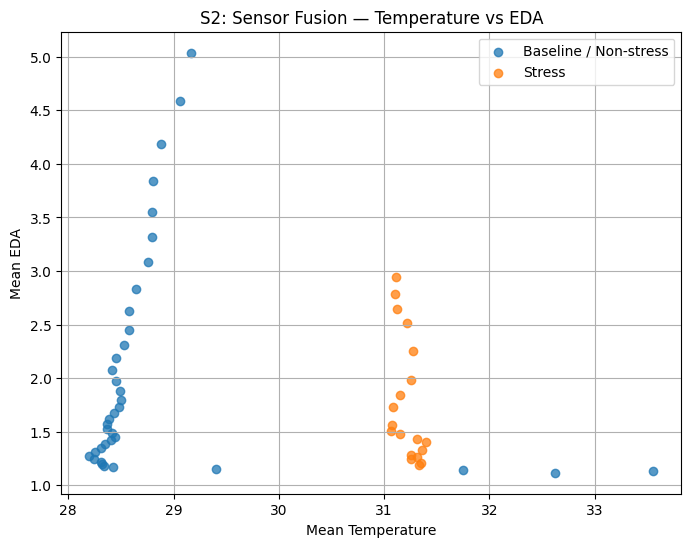

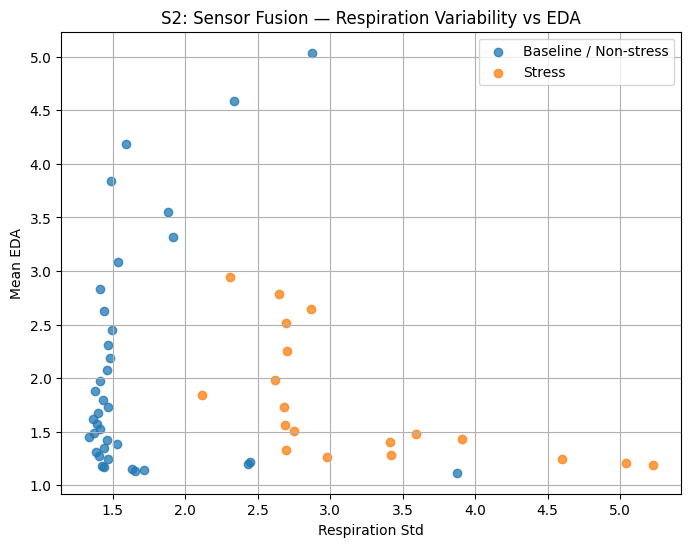

In [ ]:
# ============================================================
# STEP 10. Visualize simple sensor fusion: EDA vs TEMP/RESP/ACC
# ============================================================
label_names = {0: "Baseline / Non-stress", 1: "Stress"}

plt.figure(figsize=(8, 6))
for label in sorted(df_s2["label"].unique()):
    subset = df_s2[df_s2["label"] == label]
    plt.scatter(subset["TEMP_mean"], subset["EDA_mean"], label=label_names[label], alpha=0.75)

plt.xlabel("Mean Temperature")
plt.ylabel("Mean EDA")
plt.title(f"{SUBJECT}: Sensor Fusion — Temperature vs EDA")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
for label in sorted(df_s2["label"].unique()):
    subset = df_s2[df_s2["label"] == label]
    plt.scatter(subset["RESP_std"], subset["EDA_mean"], label=label_names[label], alpha=0.75)

plt.xlabel("Respiration Std")
plt.ylabel("Mean EDA")
plt.title(f"{SUBJECT}: Sensor Fusion — Respiration Variability vs EDA")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# STEP 11. Train small baseline classification models on S2 only
# NOTE: This is a demonstration only. For real evaluation, we will use all subjects.
# ============================================================

feature_cols = [
    c for c in df_s2.columns
    if c not in ["subject", "start_sec", "end_sec", "label"]
]

X_cls = df_s2[feature_cols]
y_cls = df_s2["label"]

if len(np.unique(y_cls)) < 2:
    raise ValueError("Only one class found. Need both baseline and stress windows.")

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.30,
    random_state=42,
    stratify=y_cls
)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train_cls, y_train_cls)
    pred_cls = model.predict(X_test_cls)

    if hasattr(model, "predict_proba"):
        prob_cls = model.predict_proba(X_test_cls)[:, 1]
        auc = roc_auc_score(y_test_cls, prob_cls)
    else:
        auc = np.nan

    acc = accuracy_score(y_test_cls, pred_cls)
    f1 = f1_score(y_test_cls, pred_cls)

    results.append({
        "model": name,
        "accuracy": acc,
        "f1": f1,
        "roc_auc": auc
    })

    print("\n" + "="*60)
    print(name)
    print("="*60)
    print("Accuracy:", acc)
    print("F1:", f1)
    print("ROC-AUC:", auc)
    print(confusion_matrix(y_test_cls, pred_cls))
    print(classification_report(y_test_cls, pred_cls))

results_df = pd.DataFrame(results)
display(results_df)


Logistic Regression
Accuracy: 1.0
F1: 1.0
ROC-AUC: 1.0
[[11  0]
 [ 0  6]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         6

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17


SVM
Accuracy: 1.0
F1: 1.0
ROC-AUC: 1.0
[[11  0]
 [ 0  6]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         6

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17


Random Forest
Accuracy: 1.0
F1: 1.0
ROC-AUC: 1.0
[[11  0]
 [ 0  6]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00 

,model,accuracy,f1,roc_auc
0,Logistic Regression,1.0,1.0,1.0
1,SVM,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0


## Mini Experiment 2: Missing-Sensor Reconstruction

This experiment evaluates whether EDA can be estimated from the remaining physiological modalities under a missing-sensor scenario.

Question:
> Can we reconstruct EDA using other physiological channels?

For this first sample, we use:
- Inputs: ECG, temperature, respiration, accelerometer features
- Target: `EDA_mean`


,Feature,Importance
16,ACC_mean,0.249369
10,TEMP_min,0.142376
1,ECG_std,0.135256
11,TEMP_max,0.081942
15,RESP_max,0.076496
3,ECG_max,0.066499
13,RESP_std,0.065618
8,TEMP_mean,0.054693
17,ACC_std,0.032452
18,ACC_min,0.026059


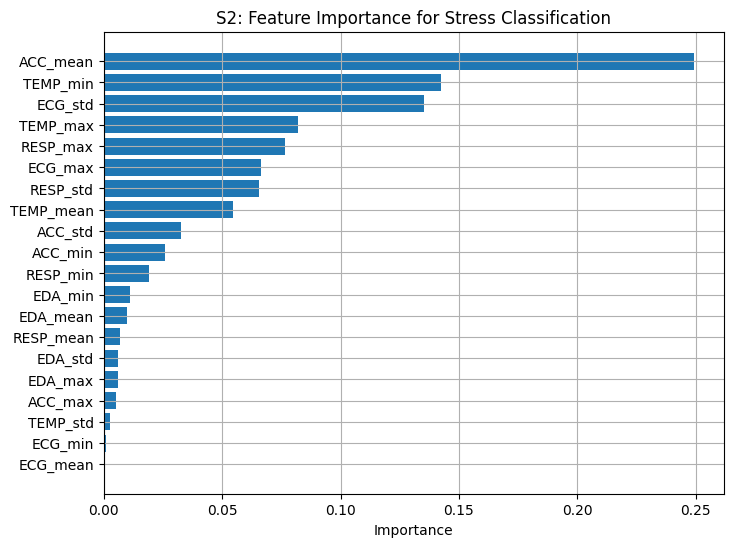

In [ ]:
# ============================================================
# STEP 11B. Feature importance from Random Forest
# ============================================================
rf_model = models["Random Forest"]

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title(f"{SUBJECT}: Feature Importance for Stress Classification")
plt.grid(True)
plt.show()

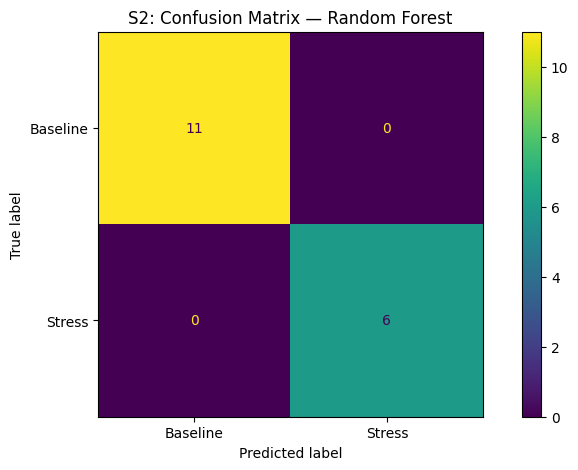

In [ ]:
# ============================================================
# STEP 11C. Confusion matrix for best baseline model
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay

best_model = models["Random Forest"]
pred_best = best_model.predict(X_test_cls)

ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    pred_best,
    display_labels=["Baseline", "Stress"]
)
plt.title(f"{SUBJECT}: Confusion Matrix — Random Forest")
plt.show()

EDA Reconstruction Results
MAE: 0.5716982103769852
RMSE: 0.8671624656608763
R2: 0.35548127760942383


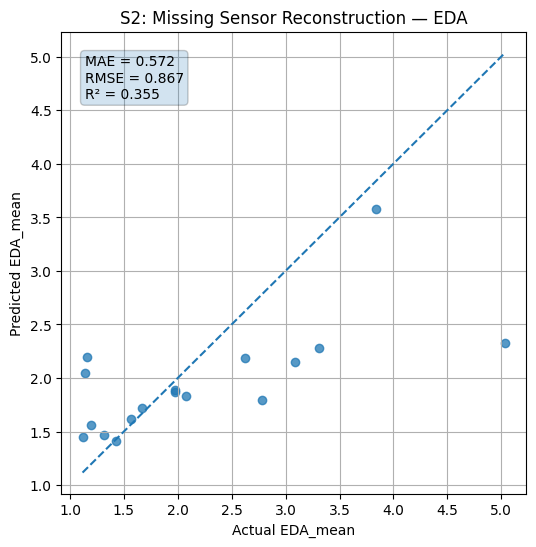

In [ ]:
# ============================================================
# STEP 12. Missing-sensor reconstruction: predict EDA_mean
# ============================================================
reconstruction_features = [
    c for c in feature_cols
    if not c.startswith("EDA_")
]

X_rec = df_s2[reconstruction_features]
y_rec = df_s2["EDA_mean"]

X_train, X_test, y_train, y_test = train_test_split(
    X_rec, y_rec,
    test_size=0.30,
    random_state=42
)

reg = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", RandomForestRegressor(n_estimators=200, random_state=42))
])

reg.fit(X_train, y_train)
pred = reg.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("EDA Reconstruction Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.75)

min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual EDA_mean")
plt.ylabel("Predicted EDA_mean")
plt.title(f"{SUBJECT}: Missing Sensor Reconstruction — EDA")

text = f"MAE = {mae:.3f}\nRMSE = {rmse:.3f}\nR² = {r2:.3f}"
plt.text(
    0.05, 0.95, text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.2)
)

plt.grid(True)
plt.show()

## Mini Experiment 3: Early Detection

This experiment evaluates short-horizon prediction by using the current window to estimate the physiological state of the subsequent window.

For a simple first test, we shift labels backward by one window:
- Features from the current window
- Predict stress state in the next window

This is a simplified early-warning prototype.


In [ ]:
# ============================================================
# STEP 13. Early stress detection: predict next-window stress
# ============================================================
df_early = df_s2.sort_values(["subject", "start_sec"]).copy()
df_early["future_label"] = df_early["label"].shift(-1)

# Remove last row with no future label
df_early = df_early.dropna(subset=["future_label"]).copy()
df_early["future_label"] = df_early["future_label"].astype(int)

print(df_early[["start_sec", "label", "future_label"]].head(10))
print(df_early["future_label"].value_counts())

X = df_early[feature_cols]
y = df_early["future_label"]

if len(np.unique(y)) < 2:
    print("Only one future class found for S2. This is okay for the sample; all-subject analysis will be stronger.")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    early_model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
    ])

    early_model.fit(X_train, y_train)
    pred = early_model.predict(X_test)
    prob = early_model.predict_proba(X_test)[:, 1]

    print("Early Detection Accuracy:", accuracy_score(y_test, pred))
    print("Early Detection F1:", f1_score(y_test, pred))
    print("Early Detection ROC-AUC:", roc_auc_score(y_test, prob))
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))

   start_sec  label  future_label
0      300.0      0             0
1      330.0      0             0
2      360.0      0             0
3      390.0      0             0
4      420.0      0             0
5      450.0      0             0
6      480.0      0             0
7      510.0      0             0
8      540.0      0             0
9      570.0      0             0
future_label
0    36
1    19
Name: count, dtype: int64
Early Detection Accuracy: 1.0
Early Detection F1: 1.0
Early Detection ROC-AUC: 1.0
[[11  0]
 [ 0  6]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         6

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



In [ ]:
# ============================================================
# STEP 14. Save processed S2 features and preliminary results
# ============================================================
s2_feature_path = os.path.join(PROCESSED_DIR, "wesad_S2_window_features.csv")
results_path = os.path.join(RESULTS_DIR, "wesad_S2_baseline_results.csv")

df_s2.to_csv(s2_feature_path, index=False)
results_df.to_csv(results_path, index=False)

print("Saved features:", s2_feature_path)
print("Saved results:", results_path)

Saved features: /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/processed/wesad_S2_window_features.csv
Saved results: /content/drive/MyDrive/Apple_Hidden_Wellness_AI/results/wesad_S2_baseline_results.csv


## Extension to the full cohort

Notebook 03 applies the same preprocessing and feature-extraction workflow to all available WESAD participants. Subject-wise validation is used to evaluate generalization to individuals excluded from model training.